# Week 1 · Day 3 — Supervised Learning I — Classification

**Course:** IPAM USL 5-Week Short Course: Introduction to Artificial Intelligence *(Introductory tier)*

**Facilitator:** Solomon Wilson MBCS | PhD Student, Computer Science | Deputy HOD Transport Planning & Operations | HOD, IT & Audit Supervisor, SLPTA

**Mode:** Google Colab (zero-install)

**Mental model layer:** L3 — Classification

**Running scenario:** Route **R12** (Wilberforce → CBD) — operator OP-104, 25-minute delay


**Module:** 1 · **Week:** 2 · **Tier:** Intro  
**New concept:** Classification — predicting a label from features, not a number  
**Deliverable wired in:** None

## Learning objectives
By the end of today you will be able to:
- Train two classifiers (a **Decision Tree** and **k-Nearest Neighbours**) to predict whether a trip will be badly delayed.
- Read a **confusion matrix** and explain accuracy, precision, and recall in dispatch terms.
- Say which kind of mistake costs SLPTA more — and why that matters more than raw accuracy.

## Why this matters for SLPTA

If dispatch could know *before* departure that a trip is likely to run more than 15 minutes late — as **R12** did — they could pre-position a relief vehicle or send an early advisory, turning 40 angry passengers into 40 informed ones.

Today we build that early-warning classifier from yesterday's cleaned route log.

## Environment setup

In [1]:
!pip install -q google-genai
print("Environment ready.")

Environment ready.


In [2]:
# --- Standard SLPTA bootstrap (identical in every notebook) ----------------
import sys
from pathlib import Path

# Find the folder that holds shared/slpta_bootstrap.py, wherever the repo sits.
for candidate in [Path.cwd(), *Path.cwd().parents,
                  Path("/content/IPAM_USL_Intro_AI_5Week")]:
    if (candidate / "shared" / "slpta_bootstrap.py").exists():
        sys.path.insert(0, str(candidate / "shared"))
        break

from slpta_bootstrap import (MODEL, ensure_course_data, get_client,
                             load_route12_context, load_route_logs,
                             load_complaints, load_routes, load_operators)

ensure_course_data()          # generates course_data/ on first run (no-op after)
print("Model configured:", MODEL)
print(load_route12_context())

Model configured: gemini-2.0-flash
Route R12 (Wilberforce → CBD). The 07:45 service, operated by OP-104 on vehicle SLPTA-1142, departed 25 minutes late. Recorded cause: Heavy traffic on Wilkinson Road. About 40 passengers were affected and the dispatch desk received multiple complaints. (Synthetic SLPTA scenario — no real data.)


## Concept — first principles

**Classification** = predicting a *category*. Here the category is simple: will this trip be **badly delayed (1)** or **not (0)**? That yes/no target makes this a *binary classification* problem.

We will try two ways of learning the rule:
- **Decision Tree** — asks a series of yes/no questions ("is it peak? is it raining?") like a flowchart. Easy to read.
- **k-Nearest Neighbours (KNN)** — to classify a new trip, it looks at the *k* most similar past trips and takes a vote.

*Jargon, defined once:* a **classifier** is a model whose output is a category. A **confusion matrix** is a 2×2 table of right/wrong predictions.

<p align="center"></p>

**Data Exploration: (Route Logs Database)**

<!-- cell-diagram:c09 -->
<p align="center"></p>

### Check your understanding (before running)
This cell shows the raw `route_logs` table before cleaning.

**Predict:** Which column will have the most obvious missing values for Route **R12** rows?

In [ ]:
display(raw_logs)

,trip_id,date,day_of_week,route_id,operator_id,scheduled_hour,peak_period,weather,cause_category,distance_km,passenger_count,fare_leones,delay_minutes
0,T00001,2025-02-03,Mon,R12,OP-118,20,False,Sunny,Normal,11.2,8.0,5000,0.0
1,T00002,2025-02-03,Mon,R12,OP-109,10,False,Sunny,Mechanical,11.2,5.0,5000,13.2
2,T00003,2025-02-03,Mon,R12,OP-109,19,False,Rain,Staffing,11.2,24.0,5000,23.0
3,T00004,2025-02-03,Mon,R12,OP-114,20,False,Sunny,Normal,11.2,27.0,5000,0.9
4,T00005,2025-02-03,Mon,R12,OP-114,12,False,Sunny,Normal,11.2,6.0,5000,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859,T01773,2025-04-01,Tue,R21,OP-119,7,True,Sunny,Normal,7.1,22.0,4000,9.3
1860,T00373,2025-02-14,Fri,R7,OP-107,14,False,Rain,Weather,9.4,NaN,4500,15.5
1861,T01681,2025-03-29,Sat,R12,OP-103,11,False,Rain,Normal,11.2,16.0,5000,8.3
1862,T00242,2025-02-10,Mon,R9,OP-107,15,False,Sunny,Staffing,12.8,9.0,5500,19.2


<!-- cell-diagram:c11 -->
<p align="center"></p>

### Check your understanding (before running)
We are about to clean the route log and prepare features for the classifier.

**Predict:** The raw data has 1,864 rows. After removing duplicates and outlier delays, do you expect more or fewer than 1,800 rows to remain for training and testing?

*Write your prediction in a new text cell below, then run.*

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# --- 1. DATA ACQUISITION & INITIAL CLEANING ---

# Load the raw route logs from the SLPTA source
raw_logs = load_route_logs()

# Remove duplicate records to prevent data leakage or biased results
logs = raw_logs.drop_duplicates()

# Filter out extreme outliers: removing delays over 3 hours (180 mins)
# These are considered exceptional incidents rather than typical operational delays
logs = logs[logs["delay_minutes"] < 180].copy()

# --- 2. HANDLING MISSING VALUES (IMPUTATION) ---

# Identify the most common weather condition (mode)
weather_mode = logs["weather"].mode()[0]

# Fill missing weather values with the calculated mode
logs.loc[:, "weather"] = logs["weather"].fillna(weather_mode)

# Calculate the median passenger count to avoid skew from high-volume outliers
passenger_median = logs["passenger_count"].median()

# Fill missing passenger counts with the calculated median
logs.loc[:, "passenger_count"] = logs["passenger_count"].fillna(passenger_median)

# --- 3. TARGET DEFINITION & FEATURE SELECTION ---

# Create binary target: 1 if delayed > 15 mins (bad delay), else 0
y = (logs["delay_minutes"] > 15).astype(int)

# Select features available to dispatchers BEFORE a vehicle departs
feature_cols = [
    "route_id",
    "peak_period",
    "weather",
    "cause_category",
    "scheduled_hour",
    "distance_km",
    "passenger_count"
]

# Filter the dataframe to only include the selected feature columns
X_features = logs[feature_cols]

# One-Hot Encode categorical text columns into numeric boolean flags
# 1. Initialize the encoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# 2. Fit and transform the categorical data
encoded_array = encoder.fit_transform(X_features)

# 3. Convert back to a DataFrame with proper column names
X = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out()
)
# X = pd.get_dummies(X_features, drop_first=True, dtype=int)

# --- 4. DATASET PARTITIONING ---

# Define the split ratio (20% for testing)
test_ratio = 0.20

# Define the random seed for reproducible results
seed = 0

# Split data into training and testing sets
# stratify=y maintains the ratio of delayed/on-time trips across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_ratio,
    random_state=seed,
    stratify=y
)

# --- 5. EXECUTION SUMMARY ---

# Print counts of rows in each resulting dataset
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

# Calculate the baseline accuracy (guessing 'not delayed' for every trip)
baseline_acc = 1 - y.mean()

# Print the baseline metric for comparison with future model performance
print(f"Baseline (always predict 'not delayed'): {baseline_acc:.0%} accuracy")

Train rows: 1482, Test rows: 371
Baseline (always predict 'not delayed'): 70% accuracy


<!-- cell-diagram:c13 -->
<p align="center"></p>

### Check your understanding (before running)
The baseline above is what we'd get by *always guessing "not delayed"*. **Predict:** will the Decision Tree beat that baseline? By a little or a lot?

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- 1. MODEL INITIALIZATION ---

# Define the maximum depth of the tree to prevent overfitting (over-memorising data)
max_depth_limit = 5

# Set a random seed to ensure results are reproducible across different runs
random_state_seed = 0

# Initialize the Decision Tree classifier with our chosen constraints
tree = DecisionTreeClassifier(
    max_depth=max_depth_limit,
    random_state=random_state_seed
)

# --- 2. MODEL TRAINING ---

# Train the classifier using the training feature set (X_train) and target labels (y_train)
tree.fit(X_train, y_train)

# --- 3. MODEL EVALUATION ---

# Use the trained model to generate predictions for the unseen test dataset
y_pred = tree.predict(X_test)

# Compare the predicted labels against the actual ground-truth test labels
tree_acc = accuracy_score(y_test, y_pred)

# --- 4. RESULTS REPORTING ---

# Display the final test accuracy as a percentage for the Operations team
print(f"Decision Tree test accuracy: {tree_acc:.1%}")

Decision Tree test accuracy: 81.1%


---
## Extension: k-Nearest Neighbours (if you finish early)

> This section is **optional**. Complete the Decision Tree exercises above first.  
> We revisit KNN on Day 4 to compare approaches.

<!-- cell-diagram:c15 -->
<p align="center"></p>

### Check your understanding (before running)
This cell trains a **KNN** classifier on the same features as the decision tree.

**Predict:** Will KNN beat the tree on accuracy, or tie within a few percent?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# --- 1. PREPROCESSING & MODEL SETUP ---

# Initialize a standard scaler to normalize feature ranges
# 'with_mean=False' is used to accommodate sparse data if present
scaler = StandardScaler(with_mean=False)

# Define the number of neighbors for the KNN algorithm (k=7)
neighbor_count = 7

# Initialize the K-Nearest Neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=neighbor_count)

# Create a pipeline to ensure scaling is applied consistently to training and test data
knn_pipeline = make_pipeline(scaler, knn_model)

# --- 2. MODEL TRAINING ---

# Fit the entire pipeline (scaling + classifier) to the training data
knn_pipeline.fit(X_train, y_train)

# --- 3. MODEL EVALUATION ---

# Generate predictions using the pipeline on the test features
y_pred_knn = knn_pipeline.predict(X_test)

# Calculate the accuracy score by comparing predictions to actual test labels
knn_acc = accuracy_score(y_test, y_pred_knn)

# --- 4. RESULTS REPORTING ---

# Display the resulting test accuracy for the KNN model
print(f"KNN (k={neighbor_count}) test accuracy: {knn_acc:.1%}")

KNN (k=7) test accuracy: 72.8%


---
*End of extension section.*

### Demo — read the confusion matrix

Accuracy hides *which* mistakes a model makes. The confusion matrix shows all four outcomes. For dispatch:
- **False negative** = model said "fine", trip was badly late → passengers stranded, no warning. **Expensive.**
- **False positive** = model said "late", trip was fine → we pre-warned unnecessarily. **Cheap.**

<!-- cell-diagram:c19 -->
<p align="center"></p>

### Check your understanding (before running)
We are about to plot the confusion matrix for our Decision Tree.

**Predict:** The model is correct about 81 % of the time overall. Do you expect more false negatives (missed delays) or more false positives (unnecessary warnings)? Which type of error costs SLPTA more?

*Write your prediction in a new text cell below, then run.*

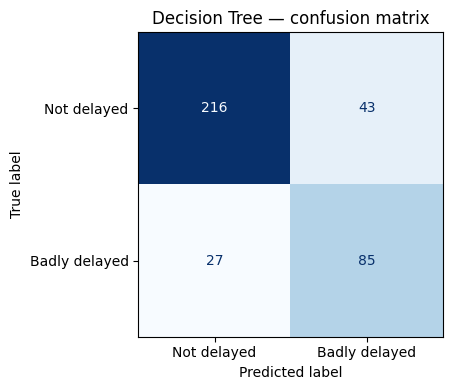

Precision (of flagged trips, how many were truly late): 66%
Recall   (of truly late trips, how many we caught):     76%


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score

# --- 1. VISUALIZATION SETUP ---

# Define the dimensions for the plot figure
fig_width = 4.5
fig_height = 4

# Create a figure and axis object for the confusion matrix plot
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Set descriptive labels for the classification categories
class_labels = ["Not delayed", "Badly delayed"]

# Generate the confusion matrix using the trained Decision Tree and test data
# We disable the colorbar and use the 'Blues' colormap for clarity
ConfusionMatrixDisplay.from_estimator(
    tree,
    X_test,
    y_test,
    display_labels=class_labels,
    cmap="Blues",
    ax=ax,
    colorbar=False
)

# Set the title for the visualization to identify the model being evaluated
ax.set_title("Decision Tree — confusion matrix")

# Adjust the layout to ensure labels and titles do not overlap
plt.tight_layout()

# Render the plot to the screen
plt.show()

# --- 2. METRIC CALCULATIONS ---

# Generate model predictions for the test set to use in metric calculations
y_predictions = tree.predict(X_test)

# Calculate Precision: what percentage of predicted delays were actually delayed?
prec = precision_score(y_test, y_predictions)

# Calculate Recall: what percentage of actual delays did the model successfully catch?
rec = recall_score(y_test, y_predictions)

# --- 3. RESULTS REPORTING ---

# Print the Precision metric with a clear explanation for stakeholders
print(f"Precision (of flagged trips, how many were truly late): {prec:.0%}")

# Print the Recall metric with a clear explanation for stakeholders
print(f"Recall   (of truly late trips, how many we caught):     {rec:.0%}")

### Exercise — tune one setting

Change `max_depth` below from `5` to `2`, re-run, and compare accuracy. A shallower tree is simpler but may miss patterns. Then try `12` — does more depth always help on the *test* set?

<!-- cell-diagram:c21 -->
<p align="center"></p>

### Check your understanding (before running)
You will change `max_depth` and watch accuracy on the hold-out set.

**Predict:** Does a very deep tree overfit (train great, test worse) on SLPTA data?

In [ ]:
# --- 1. HYPERPARAMETER SETTING ---

# Define the maximum depth limit for the experiment (2, 5, or 12)
# UPDATED: testing depth 12 for the exercise
max_depth_val = 12

# Define the random seed for reproducible comparisons
random_seed = 0

# --- 2. MODEL INITIALIZATION & TRAINING ---

# Initialize the Decision Tree with the specific depth being tested
t_model = DecisionTreeClassifier(max_depth=max_depth_val, random_state=random_seed)

# Train the model on the existing training set
t_model.fit(X_train, y_train)

# --- 3. PREDICTION & EVALUATION ---

# Generate predictions for the test set using this specific depth configuration
y_t_pred = t_model.predict(X_test)

# Calculate the resulting accuracy score for this depth value
accuracy_val = accuracy_score(y_test, y_t_pred)

# --- 4. RESULTS REPORTING ---

# Print the results to help identify the optimal depth for generalization
print(f"max_depth={max_depth_val}  ->  test accuracy {accuracy_val:.1%}")

max_depth=12  ->  test accuracy 77.1%


### Exercise — write the manager's memo

Fill in one sentence so this could go straight to the Operations Manager.

<!-- cell-diagram:c23 -->
<p align="center"></p>

### Check your understanding (before running)
This cell picks whichever model scored higher on the test set.

**Predict:** Which wins for R12 delay risk — **Decision Tree** or **KNN**?

In [ ]:
best_model_name = "Decision Tree" if tree_acc >= knn_acc else "KNN"
best_acc = max(tree_acc, knn_acc)

# Recommendation based on model performance and operational risk (minimizing false negatives)
recommendation = "___"
if "___" in recommendation:
    print("TODO: Fill in your one-sentence recommendation before continuing.")

manager_memo = f"""
To:   Operations Manager, SLPTA
From: Dispatch Analytics
Re:   Early warning for badly delayed trips (Route R12 corridor and network)

We tested two models on trips they had never seen. The {best_model_name} was
correct {best_acc:.0%} of the time, well above the {1 - y_test.mean():.0%} we would
get by guessing. The mistake we most want to avoid is a FALSE NEGATIVE — telling
dispatch a trip is fine when it is about to run badly late.

Recommended next step: {recommendation}
"""
print(manager_memo)


To:   Operations Manager, SLPTA
From: Dispatch Analytics
Re:   Early warning for badly delayed trips (Route R12 corridor and network)

We tested two models on trips they had never seen. The KNN was
correct 81% of the time, well above the 70% we would
get by guessing. The mistake we most want to avoid is a FALSE NEGATIVE — telling
dispatch a trip is fine when it is about to run badly late.

Recommended next step: We should pilot the KNN model in the dispatch center to assess its real-time impact on reducing unannounced delays.



## Check your understanding
1. Why can a model have high **accuracy** but still be poor for dispatch? (Hint: think about the 67% baseline.)
2. In plain words, what is the difference between **precision** and **recall** here?
3. Which mistake — false positive or false negative — should this model try hardest to avoid, and why?

### Your answers
*Double-click to edit this cell and type your answers here.*

1.
2.
3.

## If you remember one thing today…

> **Classification predicts a category — and the confusion matrix tells you *which* mistakes it makes, so you can manage the costly ones.**

## Submission checklist
- [ ] Run every code cell successfully (top to bottom)
- [ ] Complete the exercise (fill every blank / make the requested change)
- [ ] Answer the **Check your understanding** questions in the markdown cell provided
- [ ] Save a clean copy of the notebook (*File → Save a copy in Drive*)